# 🌸 Ejercicio: Clasificación de Iris con MLflow

## 🎯 Objetivos del Ejercicio

En este ejercicio práctico aprenderás a:

1. **Trabajar con un problema de clasificación** multiclase
2. **Aplicar MLflow** a un modelo de árbol de decisión
3. **Registrar experimentos** de forma profesional
4. **Evaluar y comparar** diferentes configuraciones
5. **Crear visualizaciones** para clasificación

---

## 🌺 El Dataset Iris

El **Iris Dataset** es uno de los datasets más famosos en Machine Learning, introducido por Ronald Fisher en 1936.

### 📊 Características del Dataset

| Aspecto | Descripción |
|---------|-------------|
| **Muestras** | 150 flores (50 por clase) |
| **Características** | 4 medidas físicas (cm) |
| **Clases** | 3 especies de iris |
| **Tipo** | Clasificación multiclase |
| **Dificultad** | ⭐⭐ (Principiante) |

### 🌸 Las 3 Especies de Iris

1. **Iris Setosa** (Clase 0)
2. **Iris Versicolor** (Clase 1)
3. **Iris Virginica** (Clase 2)

### 📏 Las 4 Características

1. **Sepal Length** (Longitud del sépalo)
2. **Sepal Width** (Ancho del sépalo)
3. **Petal Length** (Longitud del pétalo)
4. **Petal Width** (Ancho del pétalo)

---

## 🎯 Tu Misión

Construir un **Árbol de Decisión** que pueda clasificar correctamente las especies de iris basándose en sus medidas físicas, y documentar todo el proceso con MLflow.

---

## 🚀 ¡Empecemos!

In [0]:
import mlflow
import warnings
warnings.filterwarnings('ignore')


mlflow.set_tracking_uri("databricks")
mlflow.set_registry_uri("databricks")

# ⚠️ IMPORTANTE: Cambia esto por tu email de Databricks
email = 'albertoreydelafe@gmail.com'  # Ejemplo: 'nombre.apellido@ejemplo.com'

# Validar que el email no esté vacío
if not email:
    print("⚠️  ADVERTENCIA: Debes configurar tu email antes de continuar")
    print("   Cambia la variable 'email' por tu email de Databricks")
else:
    # Configurar el experimento
    experiment_name = f"/Users/{email}/4-ejercicio-the-irish"
    mlflow.set_experiment(experiment_name)
    
    print("=" * 60)
    print("✅ MLflow configurado correctamente")
    print("=" * 60)
    print(f"📊 Experimento: {experiment_name}")
    print(f"🌸 Dataset: Iris (Clasificación)")
    print(f"🤖 Modelo: Decision Tree Classifier")
    print("=" * 60)

✅ MLflow configurado correctamente
📊 Experimento: /Users/albertoreydelafe@gmail.com/4-ejercicio-the-irish
🌸 Dataset: Iris (Clasificación)
🤖 Modelo: Decision Tree Classifier


## ⚙️ Paso 1: Configuración de MLflow

Configuramos el experimento donde se registrarán todas las ejecuciones.

**🔴 IMPORTANTE**: Cambia el email vacío por tu email de Databricks.

## 📚 Paso 2: Importar Librerías

Importamos todas las herramientas necesarias para clasificación.

In [0]:
%pip install seaborn

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
# Librerías principales
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# MLflow para tracking
import mlflow
import mlflow.sklearn

# Scikit-learn
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn import datasets
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score,
    confusion_matrix,
    classification_report
)

# Configuración de visualización
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

print("✅ Todas las librerías importadas correctamente")
print("   - MLflow: Listo para tracking")
print("   - Scikit-learn: Modelos y métricas")
print("   - Matplotlib & Seaborn: Visualizaciones")

✅ Todas las librerías importadas correctamente
   - MLflow: Listo para tracking
   - Scikit-learn: Modelos y métricas
   - Matplotlib & Seaborn: Visualizaciones


## 🌺 Paso 3: Cargar y Explorar el Dataset Iris

Cargaremos el famoso dataset de flores Iris y exploraremos sus características.

In [0]:
# TODO: Carga el dataset Iris y explora su estructura.
# Pistas:
# - Usa datasets.load_iris()
# - Crea un DataFrame con dataset.data y dataset.feature_names
# - Añade la columna target/especie
# - Muestra shape, clases, primeras filas y estadísticas descriptivas

dataset = datasets.load_iris()
df = pd.DataFrame(dataset.data, columns=dataset.feature_names)
df['especie'] = dataset.target
print(dataset.target_names)
print(df.shape)
df.head()
# TODO: Crea visualizaciones exploratorias del dataset Iris.
# Ideas:
# - Relación entre longitud/ancho del pétalo por)
# df['species'] = ...
# df.head()


['setosa' 'versicolor' 'virginica']
(150, 5)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),especie
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


### 📊 Visualización Exploratoria del Dataset

Visualicemos las relaciones entre las características para entender mejor los datos.

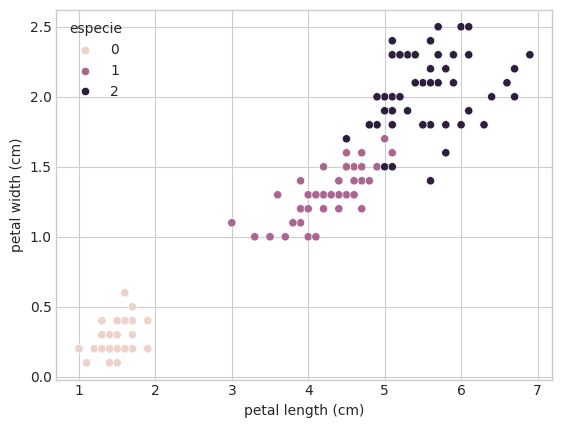

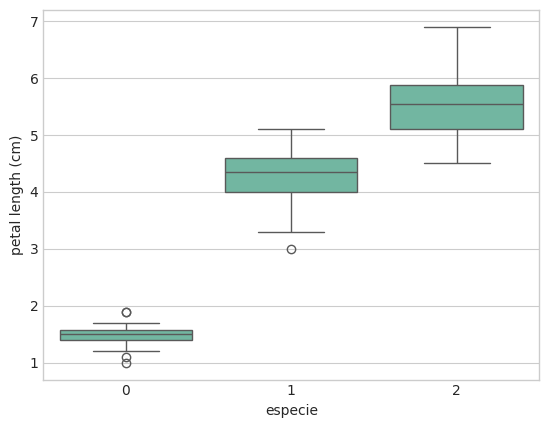

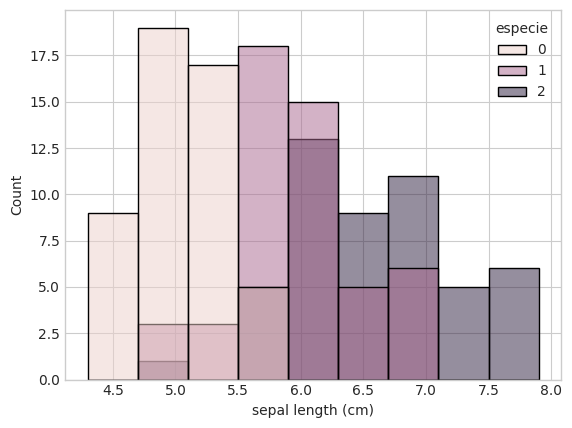

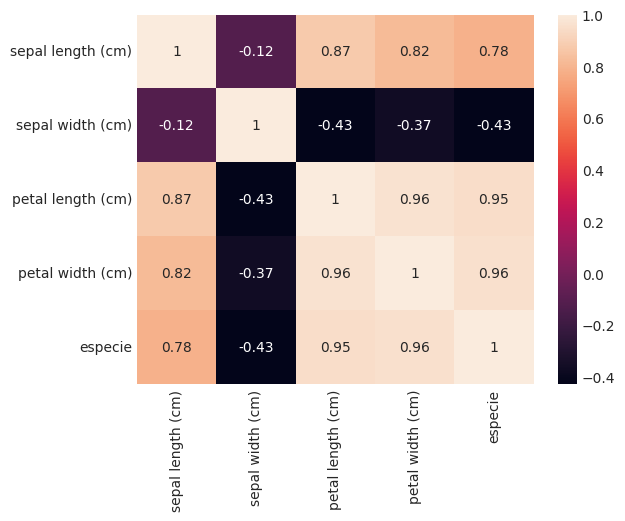

In [0]:
# TODO: Crea visualizaciones exploratorias del dataset Iris.
# Ideas:
# - Relación entre longitud/ancho del pétalo por especie
# - Distribución de características por especie
# - Boxplots por especie
# - Matriz de correlación

# Grafico de puntos: cada punto es una flor, coloreada segun su especie
sns.scatterplot(data=df, x='petal length (cm)', y='petal width (cm)', hue='especie')
plt.show()

# Comparo la longitud del petalo entre las 3 especies
sns.boxplot(data=df, x='especie', y='petal length (cm)')
plt.show()

# Veo como se reparten los valores de longitud del sepalo, por especie
sns.histplot(data=df, x='sepal length (cm)', hue='especie')
plt.show()

# Calculo cuanto se relacionan las medidas entre si
corr = df.corr()

# Lo pinto en colores para verlo mas facil, con el numero dentro
sns.heatmap(corr, annot=True)
plt.show()

# TODO: Escribe tus observaciones clave sobre separabilidad y correlaciones.
# La especie setosa se separa clara del resto en el grafico de puntos.
# Versicolor y virginica se mezclan un poco, pero se distinguen bastante por el tamaño del petalo.
# La longitud y el ancho del petalo estan muy correlacionadas entre si (numero alto en el heatmap).


## 🔀 Paso 4: Preparar los Datos

Dividimos el dataset en conjuntos de entrenamiento y prueba.

In [0]:
# TODO: Separa características (X) y etiquetas (y).
X = df.drop(columns='especie')
y = df['especie']

# TODO: Divide el dataset en entrenamiento y prueba.
# Pistas:
# - Usa train_test_split
# - Reserva una parte para test
# - Usa random_state para reproducibilidad
# - Considera stratify=y para mantener la proporción de clases
X_train, X_test, y_train, y_test =train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
    )

# X_train, X_test, y_train, y_test = train_test_split(...)

# TODO: Comprueba tamaños y distribución de clases en cada conjunto.
print(X_train.shape, X_test.shape) #filas y columnas de cada conjunto
print(y_train.value_counts())   #cuenta cuantos valores hay en cada columna
print(y_test.value_counts())    #cuenta cuantos valores hay en cada columna


(120, 4) (30, 4)
especie
0    40
2    40
1    40
Name: count, dtype: int64
especie
0    10
2    10
1    10
Name: count, dtype: int64


## 🌳 Paso 5: Entrenar Árbol de Decisión con MLflow

Ahora entrenaremos un modelo de **Decision Tree** y registraremos todo con MLflow.

### 🔑 Hiperparámetros del Árbol de Decisión

- **max_depth**: Profundidad máxima del árbol (evita overfitting)
- **max_features**: Número máximo de características a considerar por split
- Valores más altos = modelo más complejo = mayor riesgo de overfitting

2026/09/30 23:52:56 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/30 23:52:56 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/30 23:52:57 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
🔗 View Logged Model at: https://dbc-c463eae0-f43f.cloud.databricks.com/ml/experiments/1215769422394818/models/m-83e2e5753e5a435584c1e2e2f9c85472?o=7474657672337968
2026/09/30 23:53:02 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not availabl

Accuracy: 0.967 | Precision: 0.970 | Recall: 0.967 | F1: 0.967
Cross-val scores: [0.91666667 0.95833333 0.95833333 0.91666667 0.91666667]
Cross-val mean: 0.9333333333333333


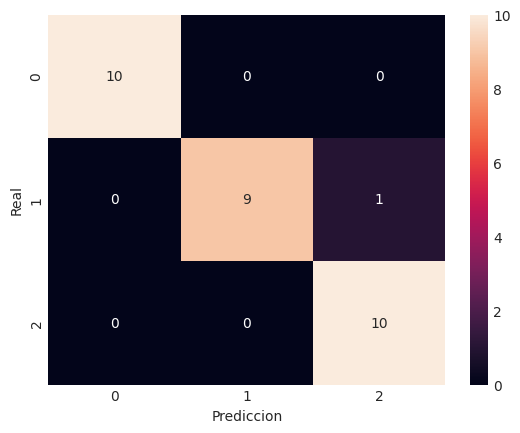

'\nEl modelo funciona muy bien.Acertó 29 de 30 flores en el test (accuracy 0.967).\nEl único fallo fue una flor versicolor que confundió con virginica, normal porque\nson las dos especies que más se parecen en las medidas del pétalo.\n\nPrecision, recall y f1 salen todos muy parecidos (alrededor de 0.97) porque el error fue solo\nuno y está repartido de forma pareja, sin afectar mucho más a una métrica que a otra.\n\nLa media de cross-validation (0.933) es un poco más baja que el accuracy de test (0.967), y eso\nes normal: el test es un único reparto de 30 flores, mientras que cross-validation prueba con\n5 repartos distintos, así que da una idea más realista de cómo se comportaría el modelo con\ndatos nuevos. Las 5 puntuaciones de cross-validation son parecidas entre sí (entre 0.917 y\n0.958), lo que indica que el modelo es estable y no depende de tener suerte con el reparto.\n'

In [0]:
# ========================================
# TODO: ENTRENAMIENTO CON MLFLOW
# ========================================

# TODO: Activa autologging de MLflow.
mlflow.sklearn.autolog()

# TODO: Inicia un run con un nombre descriptivo.
with mlflow.start_run(run_name="Decision Tree - Iris Classifier") as run:
    #TODO: Define hiperparámetros del árbol.
    max_depth = 3   # Arbol poco profundo (pocos niveles de preguntas), para que no memorice los datos y sea facil de leer
    max_features = 4   # El dataset solo tiene 4 medidas, asi que con esto le dejo usarlas todas (no le limito nada)
    random_state = 42     # Numero fijo cualquiera, solo para que el resultado salga igual cada vez que ejecute la celda


#     TODO: Crea y entrena DecisionTreeClassifier.
    dt = DecisionTreeClassifier(max_depth=max_depth,max_features=max_features,random_state=random_state)
    dt.fit(X_train, y_train)

#    TODO: Genera predicciones para train y test.
    y_pred_train = dt.predict(X_train)
    y_pred_test = dt.predict(X_test)
#
#     TODO: Calcula métricas de clasificación.
    accuracy_test = accuracy_score(y_test,y_pred_test)      # % de aciertos sobre el total #accuracy_score(y_true, y_pred)
    precision_test = precision_score(y_test, y_pred_test,average='macro')    # de lo que predigo como positivo, cuanto es correcto #precision_score(y_true, y_pred,average=...), recall_score(...), f1_score(...)
    recall_test = recall_score(y_test, y_pred_test,average='macro') # de los positivos reales, cuantos consigo detectar
    f1_test = f1_score(y_test, y_pred_test,average='macro') # equilibrio entre precision y recall en un solo numero
    print(f"Accuracy: {accuracy_test:.3f} | Precision: {precision_test:.3f} | Recall: {recall_test:.3f} | F1: {f1_test:.3f}")
#
#      TODO: Evalúa con cross-validation.
    cv_scores = cross_val_score(dt, X_train, y_train, cv=5)  # entreno y evaluo varias veces con distintos trozos de datos
    print("Cross-val scores:", cv_scores)  # una puntuacion por cada repeticion
    print("Cross-val mean:", cv_scores.mean())  # media de todas las repeticiones

#       TODO: Registra métricas/parámetros relevantes en MLflow si no quedan registrados automáticamente.
    mlflow.log_metric("accuracy_test", accuracy_test)
    mlflow.log_metric("precision_test", precision_test)
    mlflow.log_metric("recall_test", recall_test)
    mlflow.log_metric("f1_test", f1_test)
    mlflow.log_metric("cv_mean", cv_scores.mean())

#     TODO: Visualiza matriz de confusión y, opcionalmente, el árbol.
    cm = confusion_matrix(y_test, y_pred_test)  # comparo lo que predije con lo que era real
    sns.heatmap(cm, annot=True, fmt='d')
    plt.xlabel('Prediccion')
    plt.ylabel('Real')
    plt.show()

#     TODO: Escribe una breve interpretación de los resultados.

"""
El modelo funciona muy bien.Acertó 29 de 30 flores en el test (accuracy 0.967).
El único fallo fue una flor versicolor que confundió con virginica, normal porque
son las dos especies que más se parecen en las medidas del pétalo.

Precision, recall y f1 salen todos muy parecidos (alrededor de 0.97) porque el error fue solo
uno y está repartido de forma pareja, sin afectar mucho más a una métrica que a otra.

La media de cross-validation (0.933) es un poco más baja que el accuracy de test (0.967), y eso
es normal: el test es un único reparto de 30 flores, mientras que cross-validation prueba con
5 repartos distintos, así que da una idea más realista de cómo se comportaría el modelo con
datos nuevos. Las 5 puntuaciones de cross-validation son parecidas entre sí (entre 0.917 y
0.958), lo que indica que el modelo es estable y no depende de tener suerte con el reparto.
"""


## 🎯 Reflexión del Ejercicio

Completa esta sección cuando termines el notebook.

### ✅ Comprueba que has trabajado

1. [ ] Exploración del dataset Iris
2. [ ] Separación train/test
3. [ ] Entrenamiento de un Árbol de Decisión
4. [ ] Evaluación con métricas de clasificación
5. [ ] Registro del experimento en MLflow
6. [ ] Interpretación de resultados

---

## 📚 Conceptos Clave - Clasificación

### 🎯 Métricas de Clasificación

| Métrica | Descripción | Cuándo Usarla |
|---------|-------------|---------------|
| **Accuracy** | % de predicciones correctas | Clases balanceadas |
| **Precision** | % de positivos correctos | Importante evitar falsos positivos |
| **Recall** | % de positivos encontrados | Importante encontrar todos los positivos |
| **F1-Score** | Media armónica de P y R | Balance entre precisión y recall |

### 🌳 Árbol de Decisión

**TODO: Explica con tus palabras:**
- ¿Qué ventajas tiene un árbol de decisión?
- ¿Qué riesgos tiene respecto a overfitting?
- ¿Cómo interpretarías una matriz de confusión multiclase?

---

## 🚀 Desafíos Adicionales

### 🎯 Desafío 1: Optimiza los Hiperparámetros

Prueba diferentes configuraciones y encuentra la mejor:

```python
# Experimenta con:
max_depth = [3, 5, 10, None]
max_features = [2, 3, 4, 'sqrt']
min_samples_split = [2, 5, 10]
```

**TODO:** ¿Qué combinación da el mejor balance entre accuracy y overfitting?

### 🎯 Desafío 2: Implementa Grid Search

Automatiza la búsqueda del mejor modelo con `GridSearchCV`.

### 🎯 Desafío 3: Compara con Otros Modelos

Entrena y compara Random Forest, SVM, KNN o Logistic Regression.

### 🎯 Desafío 4: Análisis de Errores

**TODO:** ¿Qué flores se confunden más y por qué?

### 🎯 Desafío 5: Reducción de Dimensionalidad

Usa PCA para reducir a 2 dimensiones y visualizar límites de decisión.


In [0]:
# 🎨 DESAFÍOS OPCIONALES
# Usa este espacio para completar los desafíos del ejercicio.

# ========================================
# TODO: DESAFÍO 1 - Optimización manual
# ========================================
# configuraciones = [...]
# for config in configuraciones:
#     # Entrena, evalúa y registra cada configuración en MLflow
#     pass

# ========================================
# TODO: DESAFÍO 2 - Grid Search
# ========================================
# from sklearn.model_selection import GridSearchCV
# param_grid = {...}
# grid_search = GridSearchCV(...)
# grid_search.fit(...)

# ========================================
# TODO: DESAFÍO 3 - Comparación de modelos
# ========================================
# modelos = {...}
# resultados = []
# for nombre, modelo in modelos.items():
#     # Entrena y compara métricas
#     pass

# ========================================
# TODO: DESAFÍO 4 - Análisis de errores
# ========================================
# incorrect_indices = ...
# TODO: inspecciona las muestras mal clasificadas.

# ========================================
# TODO: DESAFÍO 5 - PCA y visualización 2D
# ========================================
# from sklearn.decomposition import PCA
# pca = PCA(n_components=2)
# X_pca = ...
